In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# import sys
from dotenv import load_dotenv
load_dotenv()

DATA_SOURCE_PATH = os.getenv("DATA_SOURCE_PATH", "../data/raw/")

#Add the path for the feature-engineered data
DATA_PROCESSED_PATH = os.getenv("DATA_PROCESSED_PATH", "../data/processed/")    
X_TRAIN_DATA_FILENAME = os.getenv("X_TRAIN_DATA_FILENAME", "X_train.csv")
X_TEST_DATA_FILENAME = os.getenv("X_TEST_DATA_FILENAME", "X_test.csv")
Y_TRAIN_LOG_DATA_FILENAME = os.getenv("Y_TRAIN_LOG_DATA_FILENAME", "y_train_log.csv")
Y_TEST_LOG_DATA_FILENAME = os.getenv("Y_TEST_LOG_DATA_FILENAME", "y_test_log.csv")
Y_TRAIN_ACTUAL_DATA_FILENAME = os.getenv("Y_TRAIN_ACTUAL_DATA_FILENAME", "y_train_actual.csv")
Y_TEST_ACTUAL_DATA_FILENAME = os.getenv("Y_TEST_ACTUAL_DATA_FILENAME", "y_test_actual.csv")
SOURCE_PATH = os.getenv("SOURCE_PATH", "../src/")

# Add src to path for custom modules
# sys.path.append(SOURCE_PATH)

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("✅ Environment setup complete!")


✅ Environment setup complete!


In [2]:
# Load your feature-engineered dataset
data_path = Path(DATA_PROCESSED_PATH)
X_train = pd.read_csv(data_path / X_TRAIN_DATA_FILENAME)
X_test = pd.read_csv(data_path / X_TEST_DATA_FILENAME)
y_train_log = pd.read_csv(data_path / Y_TRAIN_LOG_DATA_FILENAME)
y_test_log = pd.read_csv(data_path / Y_TEST_LOG_DATA_FILENAME)
y_train_actual = pd.read_csv(data_path / Y_TRAIN_ACTUAL_DATA_FILENAME)
y_test_actual = pd.read_csv(data_path / Y_TEST_ACTUAL_DATA_FILENAME)


# Print the dataset shape for X_train and X_test,Y_train_log, y_train_actual, y_test_actual

print(f"Dataset shape: {X_train.shape}")
print(f"Dataset shape: {X_test.shape}")
print(f"Dataset shape: {y_train_log.shape}")
print(f"Dataset shape: {y_test_log.shape}")
print(f"Dataset shape: {y_train_actual.shape}")
print(f"Dataset shape: {y_test_actual.shape}")  

#print columns of the dataset for X_train and X_test, y_train_log, y_train_actual, y_test_actual
print("\n--- Dataset Columns ---")
print(X_train.columns)
print(X_test.columns)
print(y_train_log.columns)
print(y_test_log.columns)
print(y_train_actual.columns)
print(y_test_actual.columns)    



FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/X_train.csv'

In [61]:
# Align columns just in case
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# y_train = train_df['log_price']
# y_test = test_df['log_price']
# train_price = train_df['price']
# test_price = test_df['price']

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Number of features:', X_train.shape[1])
print(X_test.head())
print (X_train.head())

X_train shape: (3681, 17)
X_test shape: (921, 17)
Number of features: 17
   log_sqft_living  log_sqft_lot  log_sqft_basement  sqft_per_bedroom  \
0         7.286876      7.386471           5.638355             365.0   
1         8.033009      9.431642           0.000000             770.0   
2         7.986505      8.600247           6.216606             735.0   
3         7.696667      8.902592           6.447306             550.0   
4         7.450661      9.077494           6.580639             430.0   

   basement_ratio  bedrooms_per_sqft  bathrooms_per_sqft  house_age  floors  \
0        0.191650           0.002053            0.001711          7     2.0   
1        0.000000           0.000974            0.000811         24     2.0   
2        0.170010           0.001020            0.001105         36     3.0   
3        0.286234           0.001363            0.001136         26     1.0   
4        0.418361           0.001743            0.001453         31     1.0   

   view  cond

In [62]:
# Baseline and regularized linear models
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_percentage_error

# Function to evaluate models
def evaluate_log_model(model, X_train, y_train_log, X_test, y_test_actual, y_train_actual, fit_model=True):
    """
    Evaluates models trained on Natural Log scale (np.log).
    Returns MAPE in actual dollars.
    """
    if fit_model:
        # Flatten target to 1D to avoid warnings
        y_train_flat = y_train_log.values.ravel() if hasattr(y_train_log, 'values') else np.ravel(y_train_log)
        model.fit(X_train, y_train_flat)

    # 1. Predict (output is in natural log)
    pred_log_train = model.predict(X_train)
    pred_log_test = model.predict(X_test)
    
    # 2. Inverse Transform: e^x (The inverse of np.log)
    pred_price_train = np.exp(pred_log_train)
    pred_price_test = np.exp(pred_log_test)

    # 3. Calculate MAPE (Actual $ vs Predicted $)
    train_mape = mean_absolute_percentage_error(y_train_actual, pred_price_train)
    test_mape = mean_absolute_percentage_error(y_test_actual, pred_price_test)
    
    return train_mape, test_mape


In [63]:
# linear Model Benchmarks

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

models_to_test = [
    ('OLS', LinearRegression()),
    ('Ridge', RidgeCV(alphas=np.logspace(-3, 3, 10))),
    ('Lasso', LassoCV(cv=5, random_state=42)),
    ('Elastic Net', ElasticNetCV(l1_ratio=[.1, .5, .7, .9, 1], cv=5, random_state=42))
]

linear_results = []
for name, model_alg in models_to_test:
    pipeline = Pipeline([('scaler', StandardScaler()), ('model', model_alg)])
    
    # Call the updated function
    tr_m, te_m = evaluate_log_model(
        pipeline, X_train, y_train_log, X_test, y_test_actual, y_train_actual
    )
    linear_results.append({'Model': name, 'Train_MAPE%': tr_m*100, 'Test_MAPE%': te_m*100})

# Display the leaderboard
linear_results_df = pd.DataFrame(linear_results).sort_values('Test_MAPE%')
print(linear_results_df)



         Model  Train_MAPE%  Test_MAPE%
0          OLS    22.982190   28.600504
2        Lasso    22.976969   28.646276
3  Elastic Net    22.976907   28.648078
1        Ridge    22.978262   28.651406


Running Grid Search...


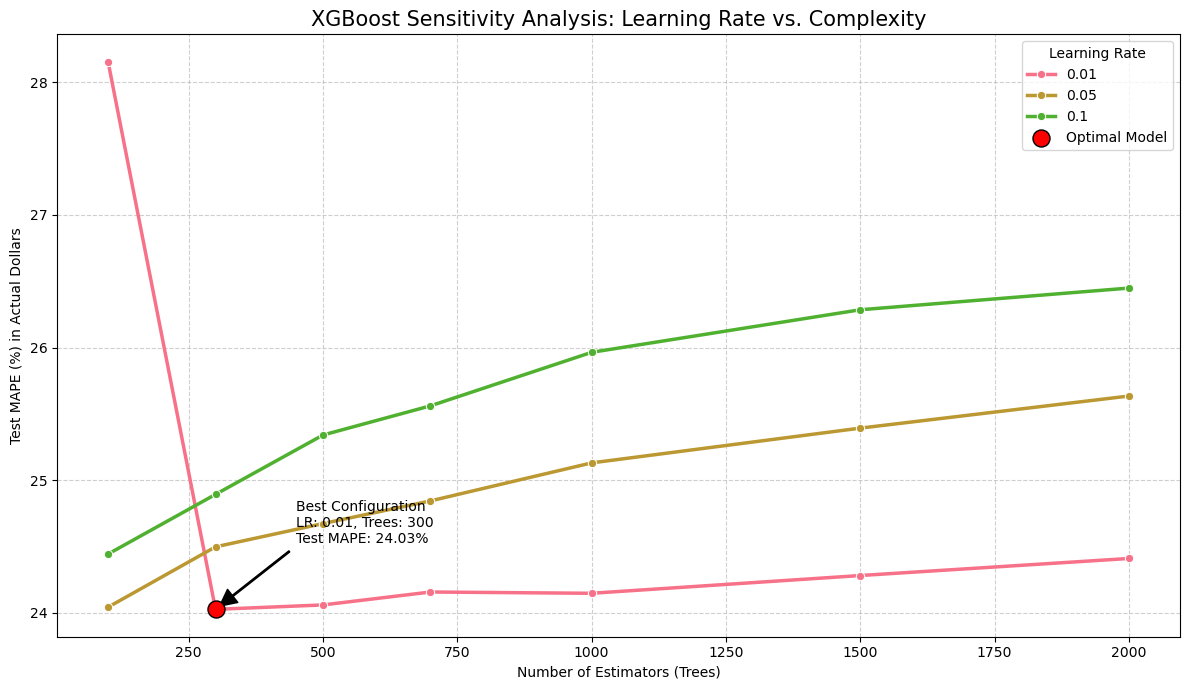

------------------------------
Best Configuration Found:
Learning Rate: 0.01
N_Estimators:  300
Train MAPE:    18.01%
Test MAPE:     24.03%
------------------------------


In [71]:
from xgboost import XGBRegressor

# 1. Define the ranges to test
learning_rates = [0.01, 0.05, 0.1]
n_estimators_range = [100, 300, 500, 700, 1000, 1500, 2000]
tuning_results = []

print("Running Grid Search...")

for lr in learning_rates:
    for n_est in n_estimators_range:
        # Initialize model
        model = XGBRegressor(
            n_estimators=n_est,
            learning_rate=lr,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
        
        # 2. Capture BOTH train and test MAPE from the function
        train_mape, test_mape = evaluate_log_model(
            model, X_train, y_train_log, X_test, y_test_actual, y_train_actual, 
            fit_model=True
        )
        
        # 3. Add BOTH to the dictionary
        tuning_results.append({
            'Learning_Rate': str(lr), 
            'N_Estimators': n_est, 
            'Train_MAPE%': train_mape * 100,  # Added this line
            'Test_MAPE%': test_mape * 100
        })

tuning_df = pd.DataFrame(tuning_results)

# --- Plotting code remains the same ---
plt.figure(figsize=(12, 7))
sns.lineplot(data=tuning_df, x='N_Estimators', y='Test_MAPE%', hue='Learning_Rate', marker='o', linewidth=2.5)

best_row = tuning_df.loc[tuning_df['Test_MAPE%'].idxmin()]
plt.scatter(best_row['N_Estimators'], best_row['Test_MAPE%'], color='red', s=150, edgecolors='black', zorder=5, label='Optimal Model')

plt.title('XGBoost Sensitivity Analysis: Learning Rate vs. Complexity', fontsize=15)
plt.xlabel('Number of Estimators (Trees)')
plt.ylabel('Test MAPE (%) in Actual Dollars')
plt.legend(title='Learning Rate')
plt.grid(True, linestyle='--', alpha=0.6)

plt.annotate(f"Best Configuration\nLR: {best_row['Learning_Rate']}, Trees: {best_row['N_Estimators']}\nTest MAPE: {best_row['Test_MAPE%']:.2f}%", 
             xy=(best_row['N_Estimators'], best_row['Test_MAPE%']),
             xytext=(best_row['N_Estimators']+150, best_row['Test_MAPE%']+0.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

# --- Printing fixed ---
print("-" * 30)
print(f"Best Configuration Found:")
print(f"Learning Rate: {best_row['Learning_Rate']}")
print(f"N_Estimators:  {best_row['N_Estimators']}")
print(f"Train MAPE:    {best_row['Train_MAPE%']:.2f}%")
print(f"Test MAPE:     {best_row['Test_MAPE%']:.2f}%")
print("-" * 30)

# Quick Comparison with OLS (if linear_results exists)
try:
    ols_test_mape = linear_results.loc[linear_results['Model'] == 'OLS', 'Test_MAPE'].values[0]
    xgb_test_mape = best_row['Test_MAPE%'] / 100
    improvement = ols_test_mape - xgb_test_mape
    if improvement > 0:
        print(f"✅ XGBoost improved accuracy by {improvement*100:.2f}% over OLS.")
    else:
        print(f"ℹ️ OLS is currently performing better than XGBoost by {abs(improvement)*100:.2f}%.")
except:
    pass


             FINAL MODEL LEADERBOARD
                          Model  Train_MAPE%  Test_MAPE%
0  XGBoost (LR:0.01, Trees:300)    18.010093   24.025594
1                           OLS    22.982190   28.600504
2                         Lasso    22.976969   28.646276
3                   Elastic Net    22.976907   28.648078
4                         Ridge    22.978262   28.651406


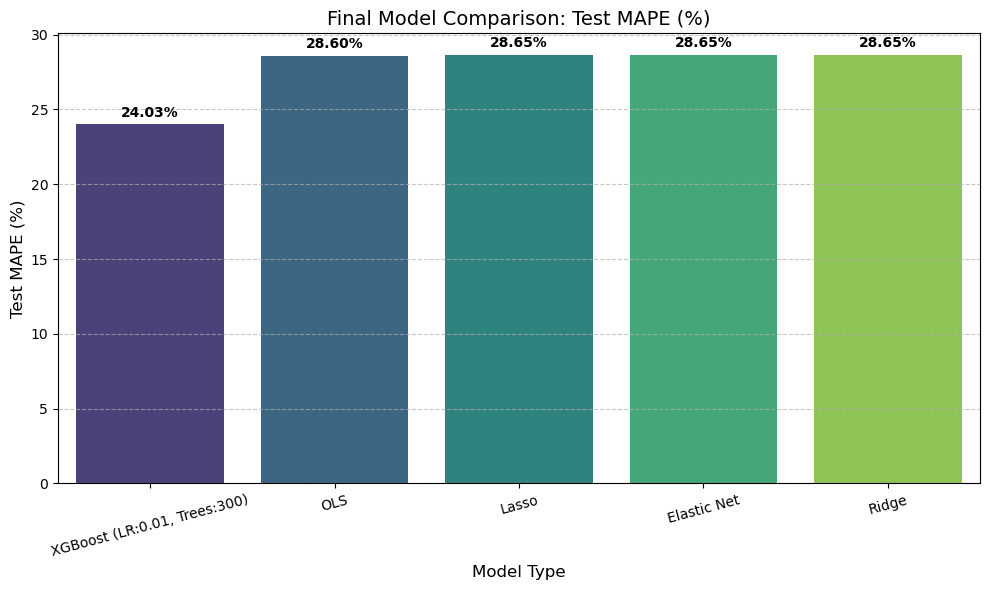

In [75]:
# Final model comparison

# 1. Start with your existing linear results
final_comparison = linear_results_df[['Model', 'Train_MAPE%', 'Test_MAPE%']].copy()

# 2. Create a row for your best XGBoost model
xgb_entry = pd.DataFrame([{
    'Model': f"XGBoost (LR:{best_row['Learning_Rate']}, Trees:{best_row['N_Estimators']})",
    'Train_MAPE%': best_row['Train_MAPE%'],
    'Test_MAPE%': best_row['Test_MAPE%']
}])

# 3. Combine the dataframes
final_comparison = pd.concat([final_comparison, xgb_entry], ignore_index=True)

# 4. Sort by Test MAPE (Best model at the top)
final_comparison = final_comparison.sort_values('Test_MAPE%').reset_index(drop=True)

# 5. Display the final leaderboard
print("="*55)
print("             FINAL MODEL LEADERBOARD")
print("="*55)
print(final_comparison)
print("="*55)

# 6. Warning-free Visualization
plt.figure(figsize=(10, 6))

# Fix: Assign 'Model' to 'hue' and set legend=False to remove the warning
sns.barplot(
    data=final_comparison, 
    x='Model', 
    y='Test_MAPE%', 
    hue='Model', 
    palette='viridis', 
    legend=False
)

plt.title('Final Model Comparison: Test MAPE (%)', fontsize=14)
plt.ylabel('Test MAPE (%)', fontsize=12)
plt.xlabel('Model Type', fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Optional: Add text labels on top of bars for clarity
for i, val in enumerate(final_comparison['Test_MAPE%']):
    plt.text(i, val + 0.5, f'{val:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

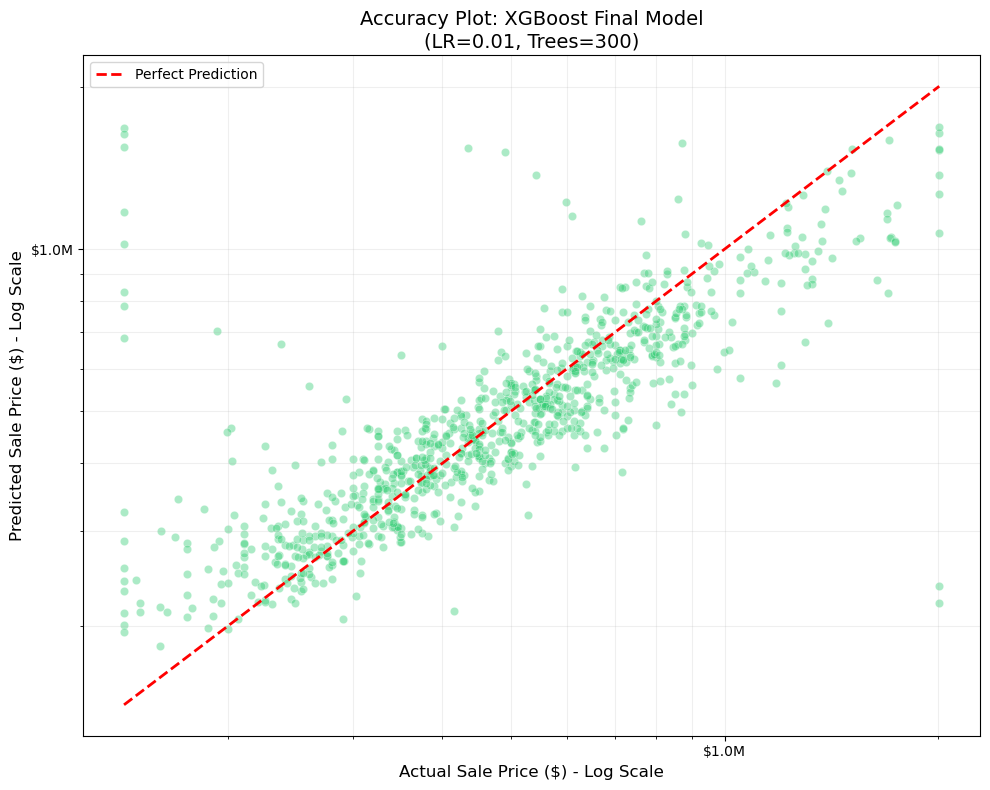

In [81]:
# Accuracy plot (Actual vs Predicted) for the best model (XGboost)
import matplotlib.ticker as ticker
import numpy as np

# 1. Re-initialize and fit
best_xgb_model = XGBRegressor(
    n_estimators=best_row['N_Estimators'],
    learning_rate=float(best_row['Learning_Rate']),
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
best_xgb_model.fit(X_train, y_train_log)

# 2. Generate and Flatten BOTH arrays
# .ravel() or np.ravel() ensures Seaborn doesn't throw a ValueError
y_pred_dollars = np.exp(best_xgb_model.predict(X_test)).ravel()
y_actual_dollars = np.ravel(y_test_actual) 

plt.figure(figsize=(10, 8))

# 3. Use Log-Log Scale to handle the "funnel" (Heteroscedasticity)
sns.scatterplot(x=y_actual_dollars, y=y_pred_dollars, alpha=0.4, color='#2ecc71', edgecolor='w')

# Set axes to log scale
plt.xscale('log')
plt.yscale('log')

# 4. Diagonal Reference Line
# On a log-log plot, the min/max must be handled carefully
limits = [min(y_actual_dollars.min(), y_pred_dollars.min()), 
          max(y_actual_dollars.max(), y_pred_dollars.max())]
plt.plot(limits, limits, 'r--', lw=2, label='Perfect Prediction')

# 5. Professional Formatting
plt.title(f"Accuracy Plot: XGBoost Final Model\n(LR={best_row['Learning_Rate']}, Trees={best_row['N_Estimators']})", fontsize=14)
plt.xlabel('Actual Sale Price ($) - Log Scale', fontsize=12)
plt.ylabel('Predicted Sale Price ($) - Log Scale', fontsize=12)

# Custom ticker to show $500k, $1M, $2M labels instead of scientific notation
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}k')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

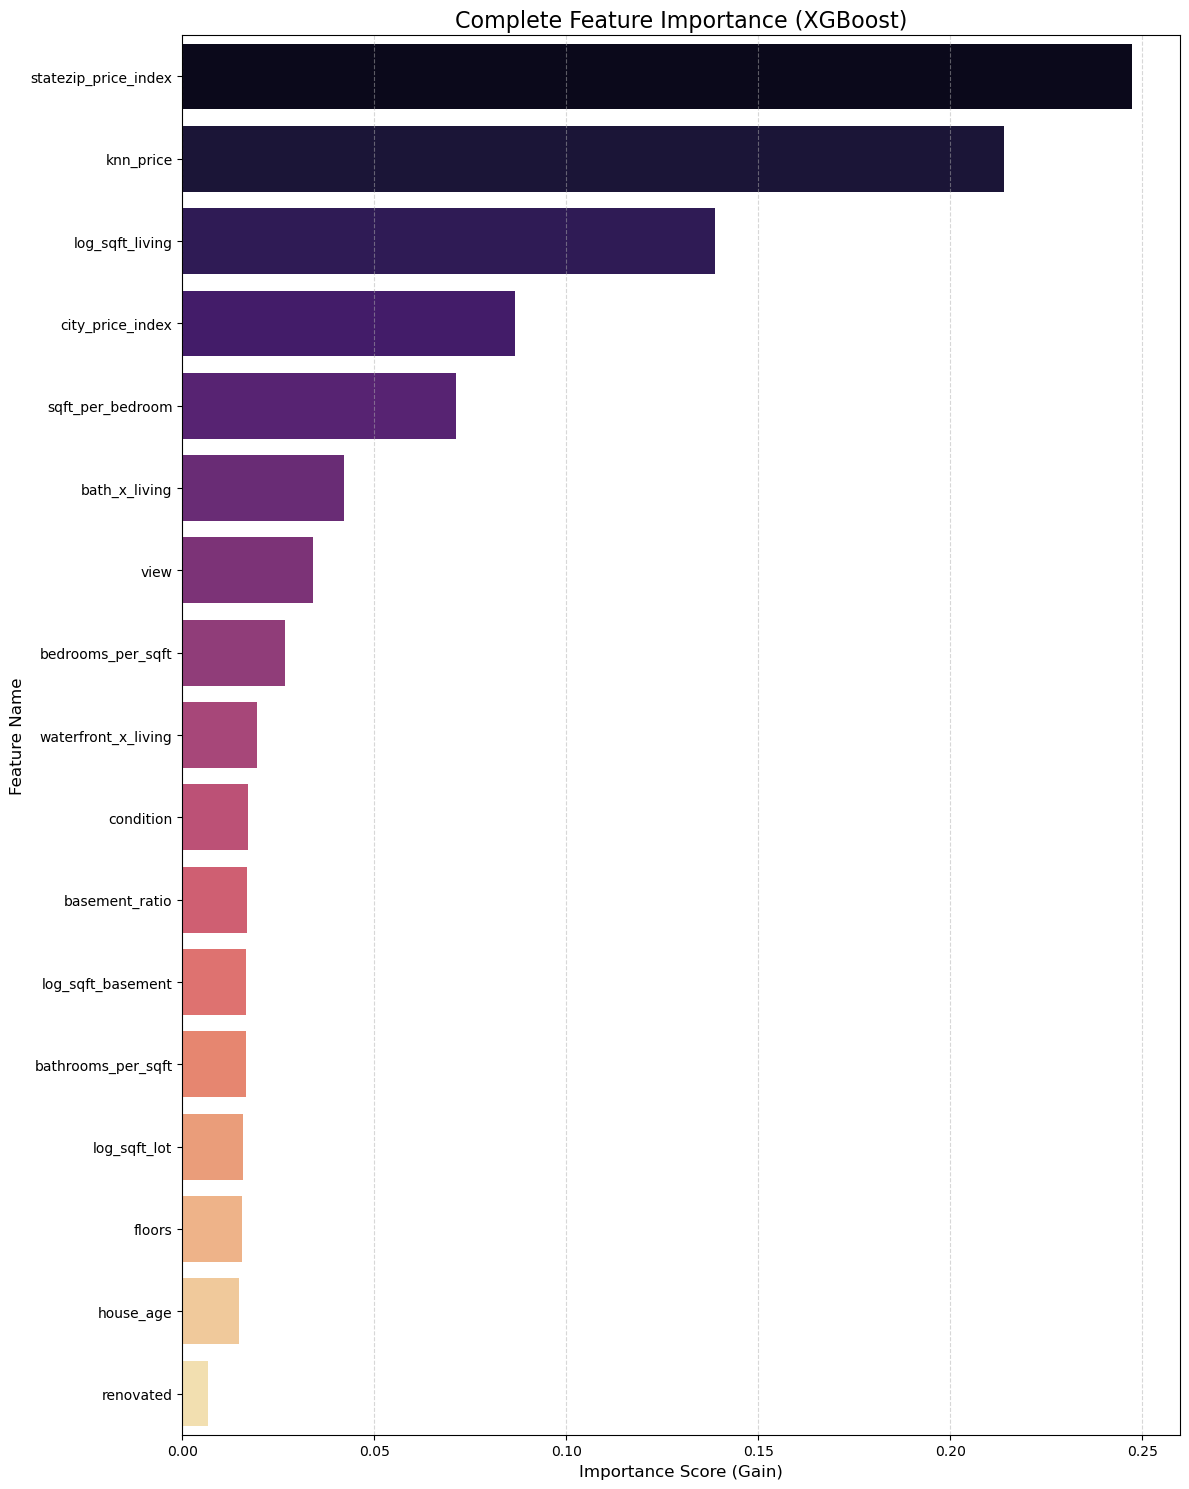

Total Features Analyzed: 17
                 Feature  Importance
0   statezip_price_index    0.247470
1              knn_price    0.214120
2        log_sqft_living    0.138738
3       city_price_index    0.086610
4       sqft_per_bedroom    0.071267
5          bath_x_living    0.042039
6                   view    0.034119
7      bedrooms_per_sqft    0.026850
8    waterfront_x_living    0.019373
9              condition    0.016996
10        basement_ratio    0.016768
11     log_sqft_basement    0.016526
12    bathrooms_per_sqft    0.016469
13          log_sqft_lot    0.015730
14                floors    0.015529
15             house_age    0.014768
16             renovated    0.006629


In [83]:
#Feature Importance Code (Plot and Table) (XGBoost)
# 1. Extract and sort all features
feature_names = X_train.columns
importances = best_xgb_model.feature_importances_

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 2. Adjust figure height based on the number of features
# If you have 30 features, height=12 or 15 is usually good.
plt.figure(figsize=(12, 15)) 

# 3. Create the barplot for the entire DataFrame
sns.barplot(
    data=fi_df, 
    x='Importance', 
    y='Feature', 
    hue='Feature',
    palette='magma',
    legend=False
)

# 4. Professional Formatting
plt.title('Complete Feature Importance (XGBoost)', fontsize=16)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 5. Full Table for Appendix
# This is often useful for the technical appendix of your report
print(f"Total Features Analyzed: {len(fi_df)}")
print(fi_df.reset_index(drop=True))

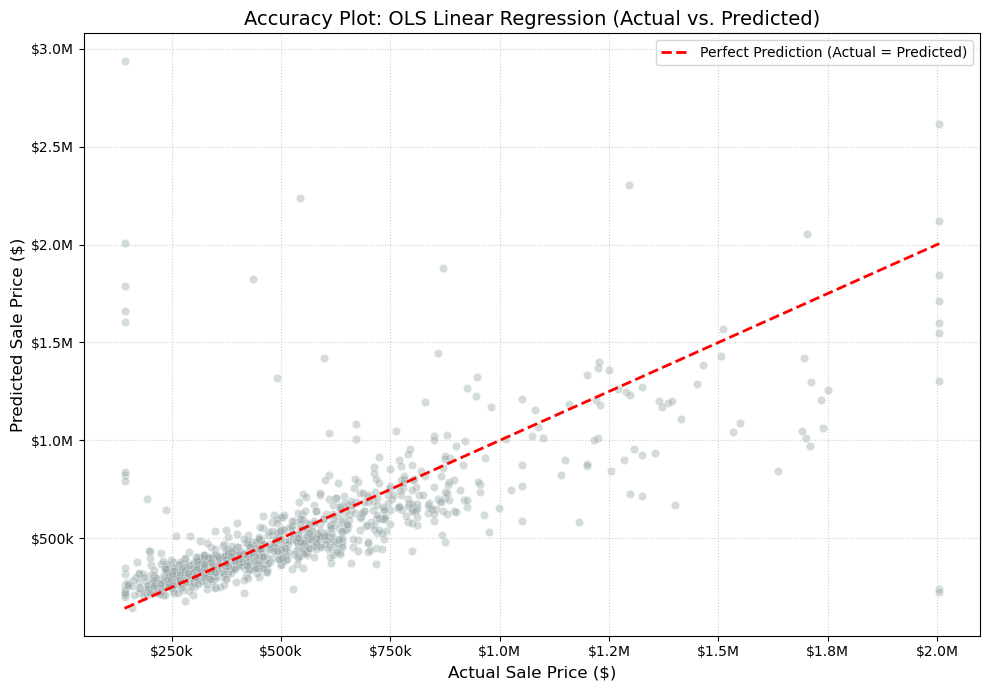

In [92]:
# Accuracy plot (Actual vs Predicted) for the best linear model (OLS).

# 1. Isolate and Fit the OLS Model
# We create a specific pipeline for OLS to ensure scaling is applied
ols_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Fit using the log-transformed target
ols_pipeline.fit(X_train, y_train_log.values.ravel())

# 2. Predict and Inverse Transform
# np.exp() converts natural log back to $
y_pred_log = ols_pipeline.predict(X_test)
y_pred_dollars = np.exp(y_pred_log).ravel()  # Ensure 1D
y_actual_dollars = np.ravel(y_test_actual)   # Ensure 1D

# 3. Create the Visualization
plt.figure(figsize=(10, 7))

# Scatter plot: Actual vs Predicted
sns.scatterplot(x=y_actual_dollars, y=y_pred_dollars, alpha=0.4, color='#95a5a6', edgecolor='w')

# 4. Add the 'Perfect Prediction' reference line
line_range = [y_actual_dollars.min(), y_actual_dollars.max()]
plt.plot(line_range, line_range, 'r--', lw=2, label='Perfect Prediction (Actual = Predicted)')

# 5. Formatting for your DSS5104 Report
plt.title('Accuracy Plot: OLS Linear Regression (Actual vs. Predicted)', fontsize=14)
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)

# Format axes to show "$1.2M" or "$500k" for readability
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}k')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()




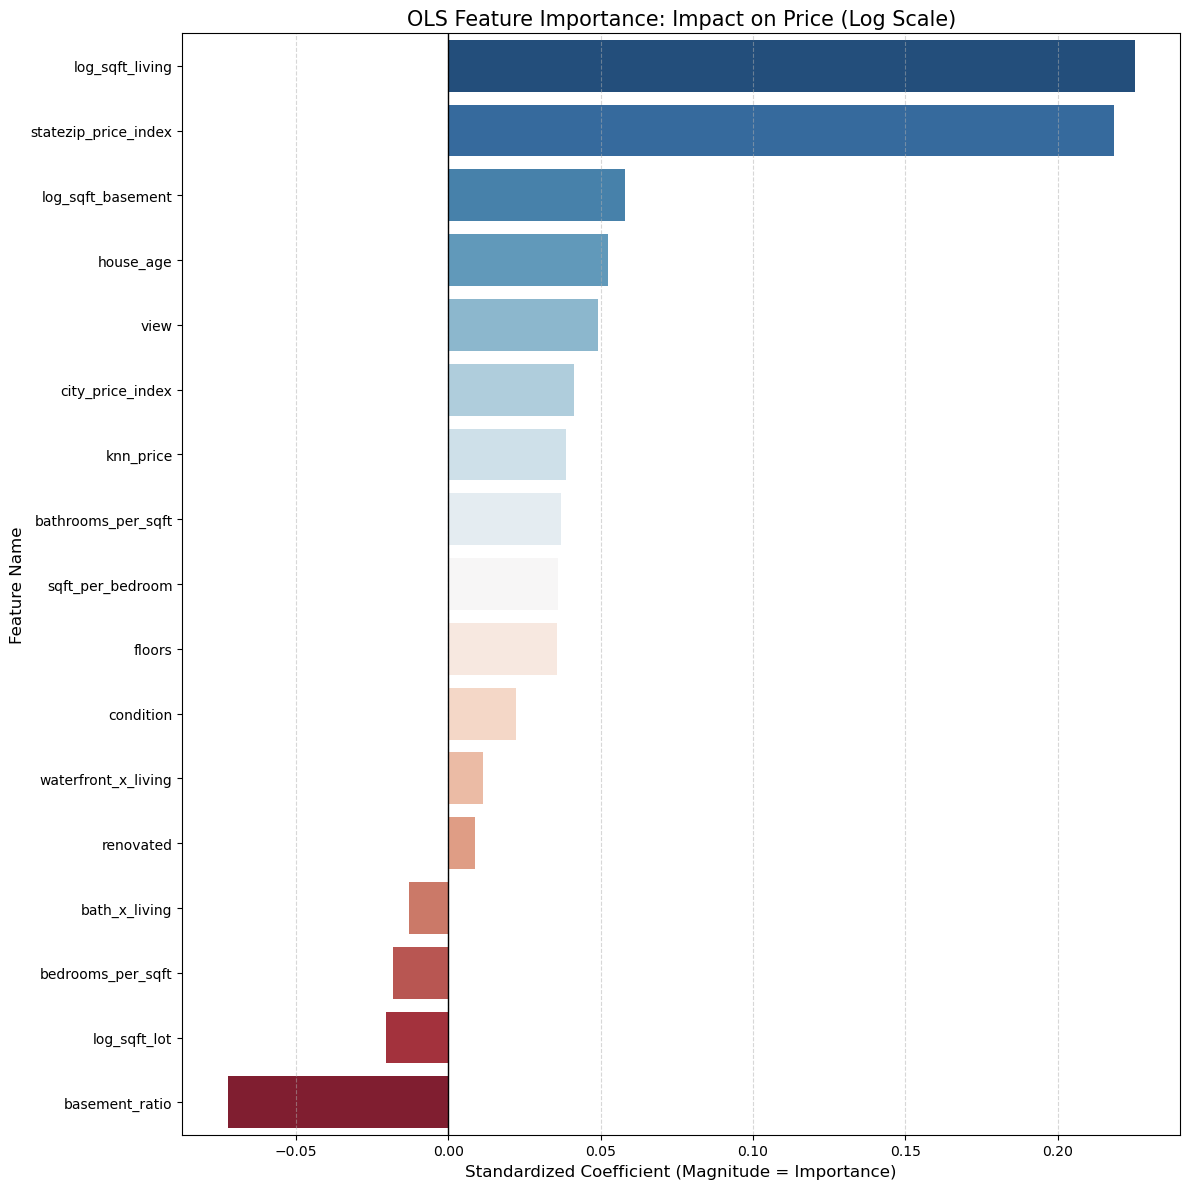

   COMPLETE OLS FEATURE IMPACT TABLE (Total: 17 Features)
                 Feature  Coefficient
0        log_sqft_living     0.225286
1   statezip_price_index     0.218650
2      log_sqft_basement     0.058140
3              house_age     0.052438
4                   view     0.049059
5       city_price_index     0.041248
6              knn_price     0.038770
7     bathrooms_per_sqft     0.036860
8       sqft_per_bedroom     0.036055
9                 floors     0.035628
10             condition     0.022160
11   waterfront_x_living     0.011371
12             renovated     0.008742
13         bath_x_living    -0.012739
14     bedrooms_per_sqft    -0.017966
15          log_sqft_lot    -0.020486
16        basement_ratio    -0.072386


In [93]:
# Feature importance plot for the best linear model (OLs)

# 1. Define the OLS Pipeline specifically
ols_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# 2. Fit the model (using your log-transformed target)
# .ravel() ensures the target is in the correct shape
ols_model.fit(X_train, y_train_log.values.ravel())

# print("OLS model fitted successfully. You can now run the feature importance plot.")

# 1. Extract feature names and coefficients
feature_names = X_train.columns
coefficients = ols_model.named_steps['model'].coef_.flatten()

# 2. Create a DataFrame for sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# 3. Plotting
plt.figure(figsize=(12, 12))
sns.barplot(
    data=importance_df, 
    x='Coefficient', 
    y='Feature', 
    hue='Feature',
    palette='RdBu_r', 
    legend=False
)

plt.axvline(0, color='black', lw=1)
plt.title('OLS Feature Importance: Impact on Price (Log Scale)', fontsize=15)
plt.xlabel('Standardized Coefficient (Magnitude = Importance)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#Full Table for Appendix
print("="*60)
print(f"   COMPLETE OLS FEATURE IMPACT TABLE (Total: {len(importance_df)} Features)")
print("="*60)
print(importance_df[['Feature', 'Coefficient']].reset_index(drop=True))
print("="*60)

